In [2]:
%pip install matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [6]:
def display_results(original, processed, title1="Original Image", title2="Processed Image"):
    """Display the original and processed images side by side"""
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(title1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap='gray')
    plt.title(title2)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [7]:
def process_image(image_path, blur_kernel=(5, 5), canny_low=5, canny_high=20, subsample_factor=10):
    """
    Process an image with edge detection and subsampling
    
    Args:
        image_path: Path to the input image
        blur_kernel: Kernel size for Gaussian blur
        canny_low: Lower threshold for Canny edge detection
        canny_high: Higher threshold for Canny edge detection
        subsample_factor: Factor by which to subsample the image
        
    Returns:
        tuple: (original image, processed image)
    """
    # Read and check if image is loaded successfully
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    display_results(img, gray, title2="Grayscale Image")

    # Apply Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray, blur_kernel, 0)
    display_results(img, blur, title2="Blurred Image")

    # Canny edge detection
    edges = cv2.Canny(blur, canny_low, canny_high)
    display_results(img, edges, title2="Canny Edges")

    # Otsu's thresholding for binarization
    _, binary = cv2.threshold(edges, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Subsampling for pixelated effect
    subsampled = binary[::subsample_factor, ::subsample_factor]

    return img, subsampled

In [8]:
def save_result(image, output_path):
    """Save the processed image to disk"""
    try:
        cv2.imwrite(output_path, image)
        print(f"Image saved to {output_path}")
        return True
    except Exception as e:
        print(f"Error saving image: {e}")
        return False


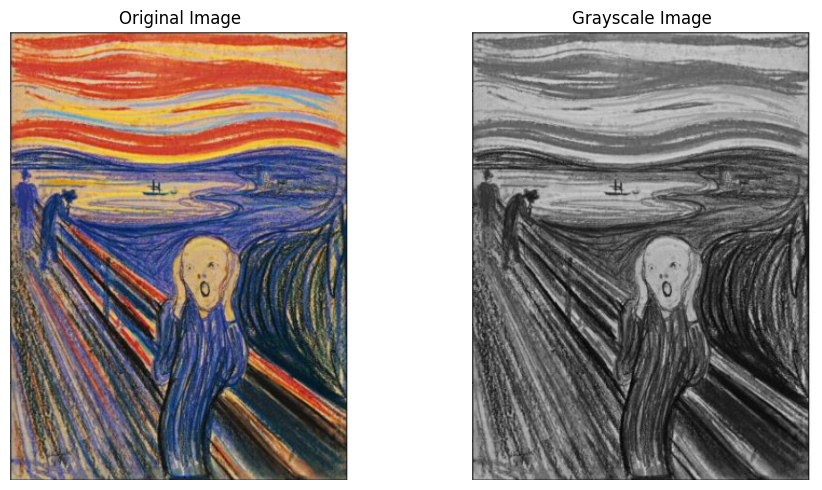

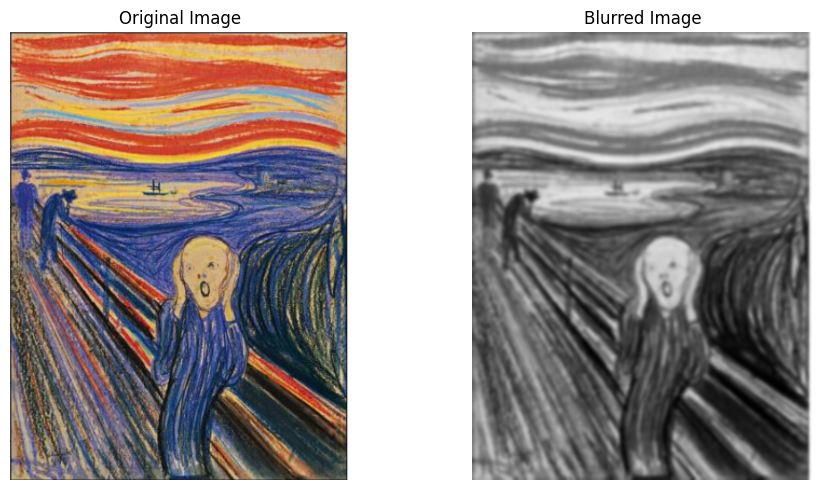

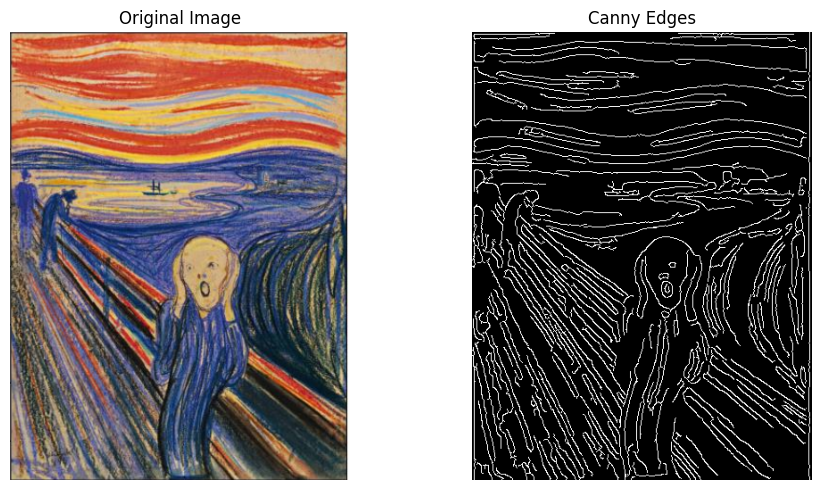

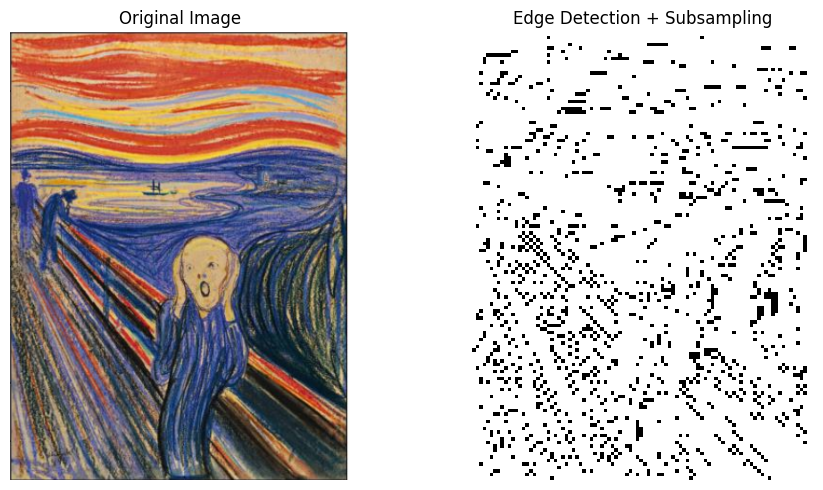

Image saved to processed_scream.jpg


In [21]:
# Configure parameters directly (no argparse needed in notebooks)
image_path = 'test.png'  # Use the image we downloaded earlier
blur_size = 10
canny_low = 11  # 大幅提高低閾值
canny_high = 100  # 大幅提高高閾值
subsample = 4
save_path = 'processed_scream.jpg'  # Optional: set to None if you don't want to save

# Ensure blur kernel size is odd
blur_kernel = (blur_size if blur_size % 2 == 1 else blur_size + 1, 
              blur_size if blur_size % 2 == 1 else blur_size + 1)

try:
    # Process the image
    original, processed = process_image(
        image_path, 
        blur_kernel=blur_kernel,
        canny_low=canny_low,
        canny_high=canny_high,
        subsample_factor=subsample
    )

    # Display results
    processed = 1 - (processed / 255)  # Invert colors for better visibility
    display_results(original, processed, "Original Image", "Edge Detection + Subsampling")

    # Save if path is specified
    if save_path:
        # Convert binary image to proper format for saving
        output_image = np.zeros((processed.shape[0], processed.shape[1]), dtype=np.uint8)
        output_image[:] = processed * 255
        output_image = 255 - output_image  # Invert black and white
        save_result(output_image, save_path)

except Exception as e:
    print(f"Error processing image: {e}")

In [22]:
def convert_image_to_binary_art(image_path, output_path, block_size=8, threshold=128):
    """
    Convert an image to binary art representation (black and white pixels).

    Parameters:
    - image_path: path to input image
    - output_path: path to save output image
    - block_size: size of pixel blocks (larger = more pixelated)
    - threshold: brightness threshold for black/white conversion (0-255)
    """

    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize down then back up to create pixelation effect
    h, w = gray.shape
    small = cv2.resize(
        gray, (w // block_size, h // block_size), interpolation=cv2.INTER_LINEAR
    )
    pixelated = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

    # Apply binary threshold to create pure black and white
    _, binary = cv2.threshold(pixelated, threshold, 255, cv2.THRESH_BINARY)

    # Save output image
    cv2.imwrite(output_path, binary)
    print(f"Binary art image saved to: {output_path}")

    # Display comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(binary, cmap="gray")
    axes[1].set_title("Binary Art (After Processing)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(
        output_path.replace(".png", "_comparison.png"), dpi=150, bbox_inches="tight"
    )
    plt.show()

    print("Comparison image also saved!")

Binary art image saved to: processed_scream.jpg


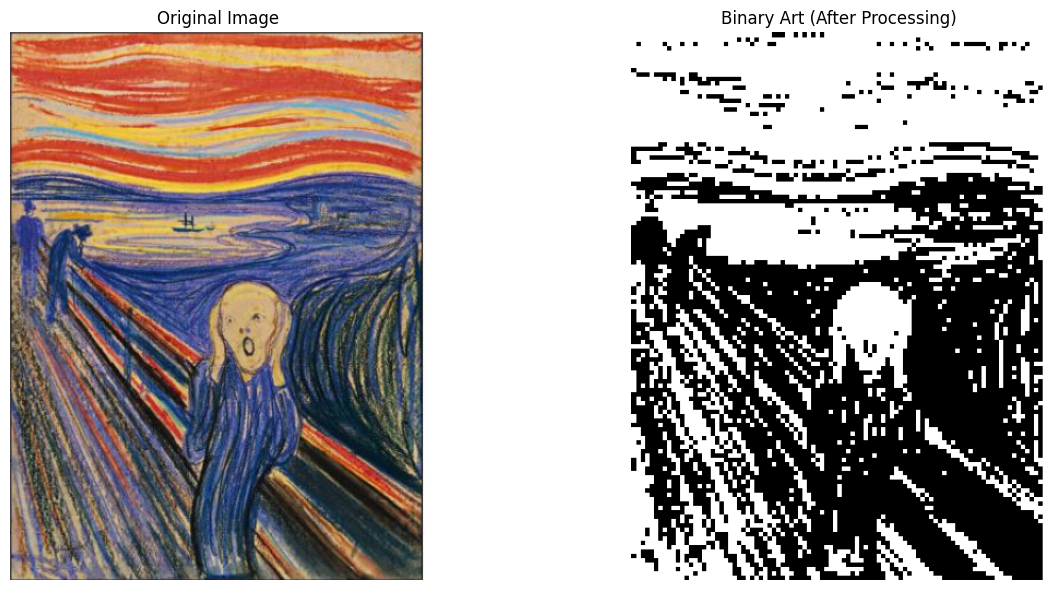

Comparison image also saved!


In [35]:
convert_image_to_binary_art(image_path, save_path, block_size=4, threshold=105)